# Forecasting Glucose Levels in Type 1 Diabetes Using Time-Series Approaches

**Student Name:** Muhammad Umer Mehmood 

**Student ID:** 23102319 

**Supervisor:** Ralf Napiwotzki    

---

## About the Dataset
The **GlucoBench** repository, which gathers extensive and longitudinal records of Continuous Glucose Monitoring (CGM) data, is the source of this dataset. Both descriptive and predictive studies are made possible by the data's integration of glucose levels with clinical, lifestyle, and demographic data.

A **single glucose measurement** from a particular patient at a particular time point is represented by each row.

## Key Features
- **Core:** Patient ID, Blood Glucose (target), Timestamp
- **Demographics:** Gender, Race, Education Level, Income, Marital Status
- **Clinical History:** Hypertension, Diabetes Duration, Comorbidities, Complications
- **Lifestyle:** Exercise Habits, Alcohol Use, Dietary Supplements
- **Medications:** Binary indicators for common prescriptions

## Purpose of Analysis
Determine the glucose patterns unique to each patient.
Conduct sophisticated statistical and visual evaluations.
Create and assess forecasting models to aid in the management of diabetes
Provide useful information about how clinical, lifestyle, and demographic factors relate to glycaemic management.

**Data Source:** [GlucoBench](https://github.com/IrinaStatsLab/GlucoBench)

# Environment Setup

## Imports & Configuration

In [2]:
# --- Core ---
import numpy as np
import pandas as pd
import os
import warnings
import random
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Preprocessing & Metrics ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Conv1D, MaxPooling1D,
                                      Dense, Dropout, Flatten,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



2026-03-22 12:51:19.426433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774183879.911578      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774183880.060424      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774183881.228754      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774183881.228806      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774183881.228809      55 computation_placer.cc:177] computation placer alr

In [3]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU is ACTIVE!")
    for gpu in gpus:
        print(f"   Device: {gpu.name}")
    # Allow memory growth to avoid OOM errors during training
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected. Running on CPU.")
    print("   → Go to Kaggle Settings > Accelerator > GPU T4 x2")

✅ GPU is ACTIVE!
   Device: /physical_device:GPU:0
   Device: /physical_device:GPU:1


In [4]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Sequence Configuration (for LSTM/GRU/CNN) ---
SEQUENCE_LENGTH  = 12   # 12 steps x 5 min = 1 hour of history as input
FORECAST_HORIZON = 6    # Predict next 6 steps = 30 minutes ahead

# --- Training Configuration ---
BATCH_SIZE    = 64
EPOCHS        = 100     # EarlyStopping will stop before if needed
PATIENCE      = 10      # EarlyStopping patience
LEARNING_RATE = 0.001

# --- Train / Val / Test Split Ratio ---
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# --- Glucose Clinical Thresholds (mg/dL) ---
HYPO_THRESHOLD  = 70    # Below = Hypoglycemia (dangerous LOW)
NORMAL_LOW      = 70
NORMAL_HIGH     = 180
HYPER_THRESHOLD = 180   # Above = Hyperglycemia (dangerous HIGH)

# --- Plot Style ---
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'glucose' : '#2196F3',
    'hypo'    : '#F44336',
    'hyper'   : '#FF9800',
    'normal'  : '#4CAF50',
    'lstm'    : '#9C27B0',
    'gru'     : '#00BCD4',
    'cnn'     : '#FF5722',
}

print("✅ Configuration set!")
print(f"   Sequence Length  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH * 5} mins of history)")
print(f"   Forecast Horizon : {FORECAST_HORIZON} steps ({FORECAST_HORIZON * 5} mins ahead)")
print(f"   Batch Size       : {BATCH_SIZE}")
print(f"   Max Epochs       : {EPOCHS}")
print(f"   Train/Val/Test   : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int(TEST_RATIO*100)}%")

✅ Configuration set!
   Sequence Length  : 12 steps (60 mins of history)
   Forecast Horizon : 6 steps (30 mins ahead)
   Batch Size       : 64
   Max Epochs       : 100
   Train/Val/Test   : 70% / 15% / 15%


# Data Loading 

In [5]:
df = pd.read_csv('/kaggle/input/datasets/umercheena/gcm-dataset/weinstock.csv')

print(f"✅ Loaded! {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"👥 Patients: {df['id'].nunique()}")
print(f"📋 Columns: {list(df.columns)}")

✅ Loaded! 647,858 rows × 41 columns
👥 Patients: 200
📋 Columns: ['id', 'gl', 'time', 'Gender', 'Race', 'EduLevel', 'AnnualInc', 'MaritalStatus', 'DaysWkEx', 'DaysWkDrinkAlc', 'DaysMonBingeAlc', 'T1DDiagAge', 'NumHospDKA', 'NumSHSinceT1DDiag', 'InsDeliveryMethod', 'UnitsInsTotal', 'NumMeterCheckDay', 'Height', 'Weight', 'Hypertension', 'Hyperlipidemia', 'Hypothyroidism', 'Depression', 'Coronary artery disease', 'Diabetic peripheral neuropathy', 'Dyslipidemia', 'Chronic kidney disease', 'Osteoporosis', 'Proliferative diabetic retinopathy', 'Hypercholesterolemia', 'Erectile dysfunction', 'Type I diabetes mellitus', 'Aspirin', 'Simvastatin', 'Lisinopril', 'Vitamin D', 'Multivitamin preparation', 'Omeprazole', 'atorvastatin', 'Synthroid', 'vitamin D3']


In [6]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['id', 'time']).reset_index(drop=True)

print(f"✅ Datetime parsed and sorted!")
print(f"   Time range: {df['time'].min()}  →  {df['time'].max()}")
print(f"   Sample:\n{df[['id', 'gl', 'time']].head(5)}")

✅ Datetime parsed and sorted!
   Time range: 1899-12-27 20:28:58  →  1900-03-22 12:33:51
   Sample:
   id     gl                time
0   1  223.0 1900-01-01 18:35:14
1   1  221.0 1900-01-01 18:40:14
2   1  233.0 1900-01-01 18:45:14
3   1  223.0 1900-01-01 18:50:14
4   1  214.0 1900-01-01 18:55:14


# 1. Exploratory Data Analysis (EDA)

## Statistics on Glucose
There are 647,858 readings in the dataset with **no missing values**, thus no imputation is necessary.
A poorly controlled T1D population with excessive glucose variability is indicated by a mean glucose of **173.86 mg/dL** around the hyperglycemia threshold and a high standard deviation of **82.54 mg/dL**.

In [7]:
print("📊 Glucose (gl) Statistics:")
print(df['gl'].describe().round(2))

print(f"\n🔴 Hypoglycemia  (< 70 mg/dL)  : {(df['gl'] < 70).sum():,}  ({(df['gl'] < 70).mean()*100:.1f}%)")
print(f"🟢 Normal        (70–180 mg/dL) : {((df['gl'] >= 70) & (df['gl'] <= 180)).sum():,}  ({((df['gl'] >= 70) & (df['gl'] <= 180)).mean()*100:.1f}%)")
print(f"🟠 Hyperglycemia (> 180 mg/dL)  : {(df['gl'] > 180).sum():,}  ({(df['gl'] > 180).mean()*100:.1f}%)")

print(f"\n❓ Missing glucose values: {df['gl'].isnull().sum()}")

📊 Glucose (gl) Statistics:
count    647858.00
mean        173.86
std          82.54
min          39.00
25%         112.00
50%         161.00
75%         223.00
max         401.00
Name: gl, dtype: float64

🔴 Hypoglycemia  (< 70 mg/dL)  : 48,839  (7.5%)
🟢 Normal        (70–180 mg/dL) : 333,033  (51.4%)
🟠 Hyperglycemia (> 180 mg/dL)  : 265,986  (41.1%)

❓ Missing glucose values: 0


## Distribution of Glucose
The histogram has a **right-skewed distribution** with a prominent spike at 401 mg/dL, which represents the maximum reading cap of the CGM sensor; preprocessing will take care of this.

The skew brought on by extremely high blood sugar levels is confirmed by Mean (173.9) > Median (161.0).

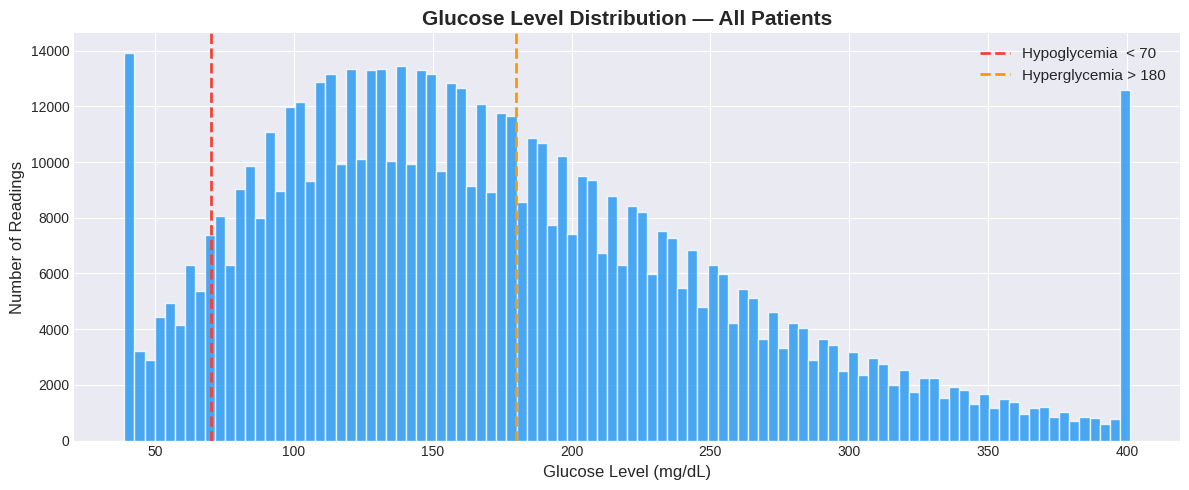

Mean  : 173.9 mg/dL
Median: 161.0 mg/dL
Std   : 82.5 mg/dL


In [8]:
plt.figure(figsize=(12, 5))

plt.hist(df['gl'], bins=100, color=COLORS['glucose'], edgecolor='white', alpha=0.8)

# Clinical threshold lines
plt.axvline(HYPO_THRESHOLD,  color=COLORS['hypo'],   linewidth=2, linestyle='--', label='Hypoglycemia  < 70')
plt.axvline(HYPER_THRESHOLD, color=COLORS['hyper'],  linewidth=2, linestyle='--', label='Hyperglycemia > 180')

plt.title('Glucose Level Distribution — All Patients', fontsize=15, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Number of Readings', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Mean  : {df['gl'].mean():.1f} mg/dL")
print(f"Median: {df['gl'].median():.1f} mg/dL")
print(f"Std   : {df['gl'].std():.1f} mg/dL")

## Distribution of Glucose Zones
Patients spend over half of their time in hazardous glucose zones since only **51.4%** of values fall inside the normal range. The high rate of **41.1%** hyperglycemia significantly 

explains why a precise deep learning forecasting method is necessary.

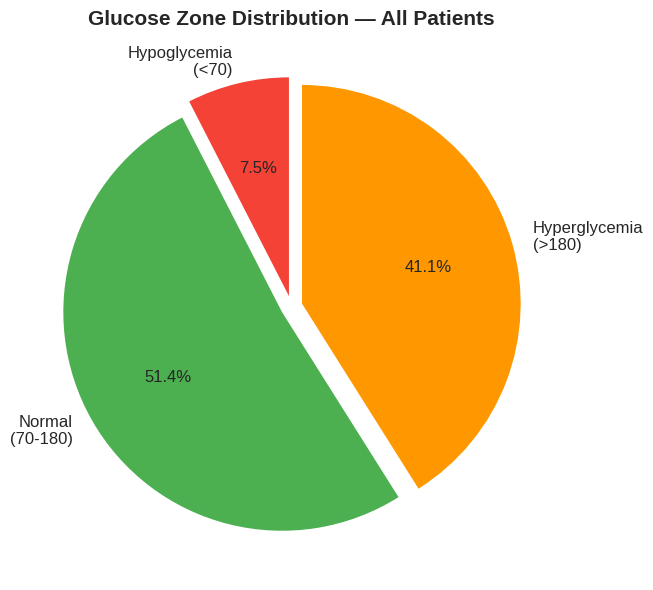

In [9]:
zones       = ['Hypoglycemia\n(<70)', 'Normal\n(70-180)', 'Hyperglycemia\n(>180)']
zone_counts = [
    (df['gl'] < 70).sum(),
    ((df['gl'] >= 70) & (df['gl'] <= 180)).sum(),
    (df['gl'] > 180).sum()
]
zone_colors = [COLORS['hypo'], COLORS['normal'], COLORS['hyper']]

plt.figure(figsize=(8, 6))
plt.pie(zone_counts,
        labels=zones,
        colors=zone_colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05, 0.05),
        textprops={'fontsize': 12})

plt.title('Glucose Zone Distribution — All Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Patient Time Series 
Patient 1 exhibits extremely **volatile and non-linear** glucose patterns, with a mean of **213.8 mg/dL** with quick spikes and dips within brief periods. The use of sequence-based deep learning models such as CNN, GRU, and LSTM is directly justified by this chaotic behaviour.

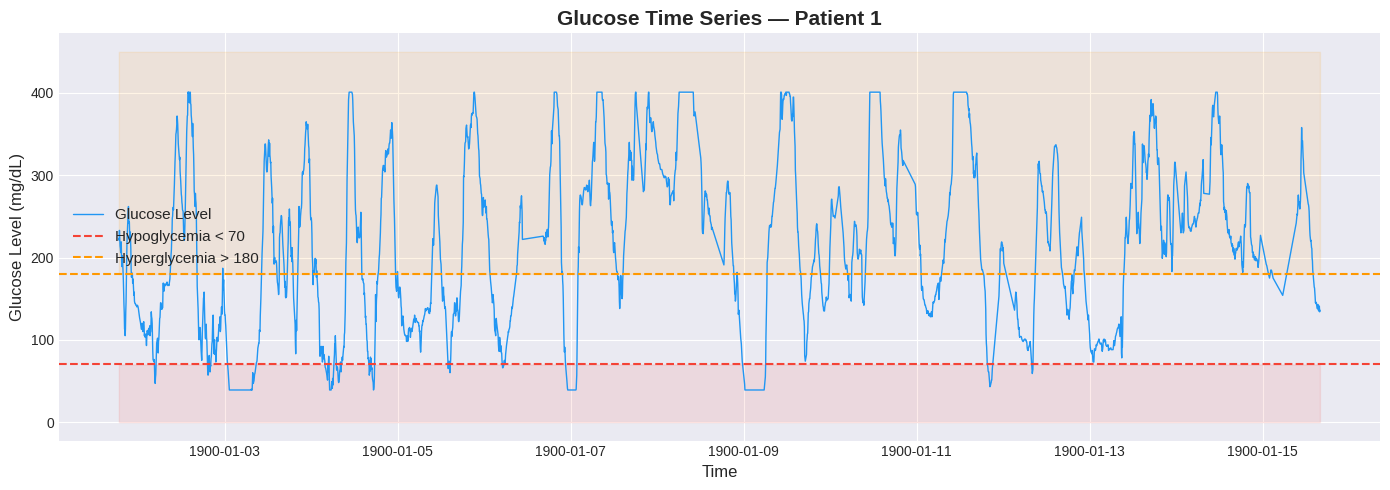

Patient 1 — Total readings : 3327
Mean glucose : 213.8 mg/dL


In [10]:
# Pick patient ID 1 as sample
patient = df[df['id'] == 1].copy()

plt.figure(figsize=(14, 5))

plt.plot(patient['time'], patient['gl'], 
         color=COLORS['glucose'], linewidth=1, label='Glucose Level')

# Clinical threshold lines
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, 
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, 
            linestyle='--', label='Hyperglycemia > 180')

# Shade danger zones
plt.fill_between(patient['time'], 0, HYPO_THRESHOLD, 
                 alpha=0.1, color=COLORS['hypo'])
plt.fill_between(patient['time'], HYPER_THRESHOLD, 450, 
                 alpha=0.1, color=COLORS['hyper'])

plt.title('Glucose Time Series — Patient 1', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Patient 1 — Total readings : {len(patient)}")
print(f"Mean glucose : {patient['gl'].mean():.1f} mg/dL")

## Statistics by Patient
Patient data durations vary, with readings per patient ranging from **432 to 5,146**.
Personalised glucose forecasting models are necessary since the average of the top 10 patients is above **235 mg/dL**, indicating significant inter-patient variability.

In [11]:
patient_stats = df.groupby('id')['gl'].agg(
    Total_Readings = 'count',
    Mean_Glucose   = 'mean',
    Std_Glucose    = 'std',
    Min_Glucose    = 'min',
    Max_Glucose    = 'max'
).round(1).reset_index()

print("📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):")
print(patient_stats.sort_values('Mean_Glucose', ascending=False).head(10).to_string(index=False))

print(f"\n📈 Average readings per patient : {patient_stats['Total_Readings'].mean():.0f}")
print(f"📈 Overall mean glucose         : {patient_stats['Mean_Glucose'].mean():.1f} mg/dL")
print(f"📈 Most readings in one patient : {patient_stats['Total_Readings'].max()}")
print(f"📈 Least readings in one patient: {patient_stats['Total_Readings'].min()}")

📊 Per Patient Glucose Statistics (Top 10 by Mean Glucose):
 id  Total_Readings  Mean_Glucose  Std_Glucose  Min_Glucose  Max_Glucose
175            1838         265.4        111.5         44.0        401.0
171            2916         264.8         93.4         39.0        401.0
147            1869         248.2         99.4         39.0        401.0
166            2110         246.2         96.6         39.0        401.0
153            3007         243.7         96.9         65.0        401.0
 94            3713         242.2         71.6         82.0        401.0
 79             457         239.4         76.6        105.0        401.0
203            2316         237.3        119.3         39.0        401.0
184            1250         237.1         71.4         58.0        401.0
 93            3739         236.0         96.3         39.0        401.0

📈 Average readings per patient : 3239
📈 Overall mean glucose         : 175.3 mg/dL
📈 Most readings in one patient : 5146
📈 Least readings

## Time Gap Analysis
The majority of readings follow the expected 5-minute CGM sampling interval.
Large gaps (> 30 minutes) indicate missing readings periods, likely due to
sensor removal or device malfunction—these will need careful handling
during sequence creation to avoid feeding misleading patterns to the models.

📊 Time Gap Between Readings (minutes):
count    647658.00
mean          6.85
std         151.93
min           0.48
25%           5.00
50%           5.00
75%           5.00
max       66678.08
Name: time_diff, dtype: float64

✅ Exact 5-min gaps  : 610,852  (94.3%)
✅ Within 6 min gaps : 624,552  (96.4%)
⚠️  Gaps > 30 minutes : 2,553  (0.4%)


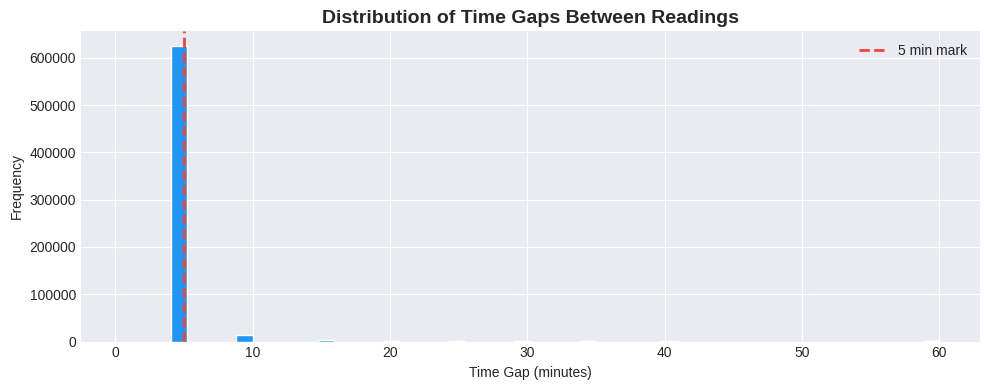

In [12]:
df['time_diff'] = df.groupby('id')['time'].diff().dt.total_seconds() / 60  # in minutes

# Overall stats
print("📊 Time Gap Between Readings (minutes):")
print(df['time_diff'].describe().round(2))

# How many gaps are exactly 5 minutes
exact_5 = (df['time_diff'] == 5).sum()
within_6 = (df['time_diff'] <= 6).sum()
large_gaps = (df['time_diff'] > 30).sum()

print(f"\n✅ Exact 5-min gaps  : {exact_5:,}  ({exact_5/df['time_diff'].notna().sum()*100:.1f}%)")
print(f"✅ Within 6 min gaps : {within_6:,}  ({within_6/df['time_diff'].notna().sum()*100:.1f}%)")
print(f"⚠️  Gaps > 30 minutes : {large_gaps:,}  ({large_gaps/df['time_diff'].notna().sum()*100:.1f}%)")

# Plot distribution of time gaps
plt.figure(figsize=(10, 4))
df['time_diff'].dropna().clip(upper=60).hist(bins=50, color=COLORS['glucose'], edgecolor='white')
plt.axvline(5, color=COLORS['hypo'], linewidth=2, linestyle='--', label='5 min mark')
plt.title('Distribution of Time Gaps Between Readings', fontsize=14, fontweight='bold')
plt.xlabel('Time Gap (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Rolling Mean Visualization
The 1-hour rolling mean smooths out short-term glucose spikes while preserving
the overall trend, revealing clear cyclical patterns of highs and lows throughout
the day. The 3-hour rolling mean shows the broader glucose trajectory, confirming
that this patient spends the majority of time in the hyperglycemic zone—a pattern
Our deep learning models must learn to forecast accurately.

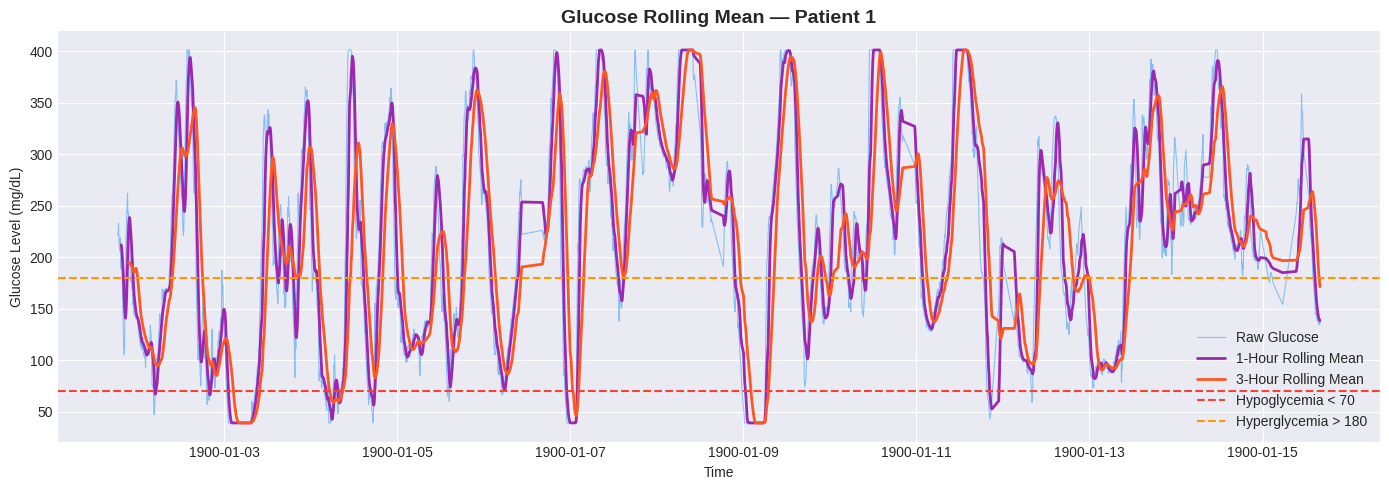

In [13]:
patient = df[df['id'] == 1].copy().reset_index(drop=True)

# Calculate rolling mean with different windows
patient['rolling_mean_12'] = patient['gl'].rolling(window=12).mean()  # 1 hour
patient['rolling_mean_36'] = patient['gl'].rolling(window=36).mean()  # 3 hours

plt.figure(figsize=(14, 5))

# Raw glucose
plt.plot(patient['time'], patient['gl'],
         color=COLORS['glucose'], linewidth=0.8, alpha=0.5, label='Raw Glucose')

# Rolling means
plt.plot(patient['time'], patient['rolling_mean_12'],
         color=COLORS['lstm'], linewidth=2, label='1-Hour Rolling Mean')
plt.plot(patient['time'], patient['rolling_mean_36'],
         color=COLORS['cnn'], linewidth=2, label='3-Hour Rolling Mean')

# Clinical thresholds
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5,
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5,
            linestyle='--', label='Hyperglycemia > 180')

plt.title('Glucose Rolling Mean — Patient 1', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Glucose by Hour of Day
The plot reveals a clear daily glucose pattern—levels tend to be lower during
early morning hours (likely fasting/sleep period) and rise during daytime hours,
corresponding to meals and activity. The wide standard deviation band confirms
high variability between patients at every hour, reinforcing the need for
patient-specific forecasting models rather than a single global model.

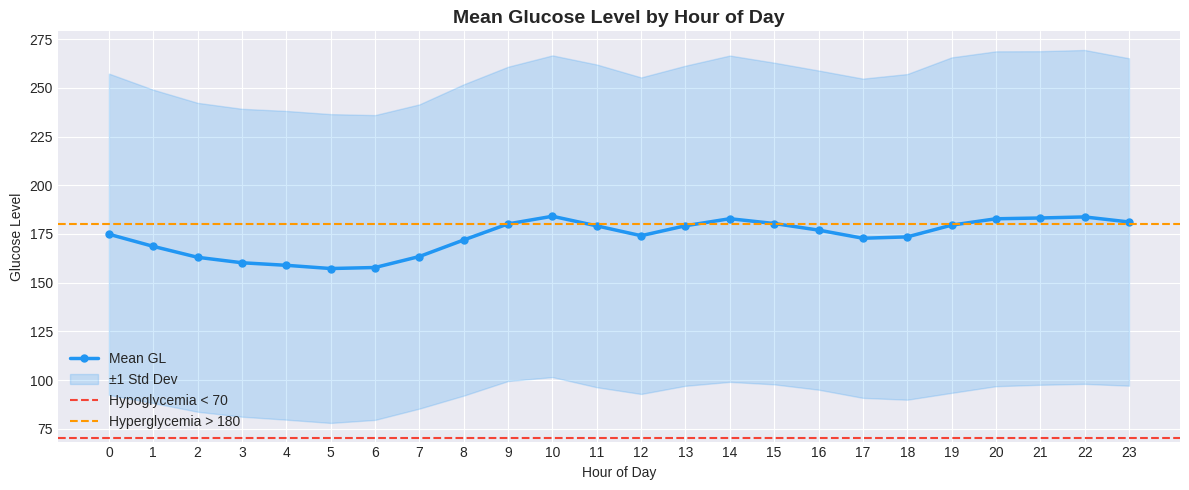

In [14]:
# Recreate hour column first
df['hour'] = df['time'].dt.hour

# Recreate hourly_stats
hourly_stats = df.groupby('hour')['gl'].agg(['mean', 'std']).reset_index()
hourly_stats.columns = ['hour', 'mean_gl', 'std_gl']

plt.figure(figsize=(12, 5))

plt.plot(hourly_stats['hour'], hourly_stats['mean_gl'],
         color=COLORS['glucose'], linewidth=2.5, marker='o', markersize=5, label='Mean GL')

plt.fill_between(hourly_stats['hour'],
                 hourly_stats['mean_gl'] - hourly_stats['std_gl'],
                 hourly_stats['mean_gl'] + hourly_stats['std_gl'],
                 alpha=0.2, color=COLORS['glucose'], label='±1 Std Dev')

plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5,
            linestyle='--', label='Hypoglycemia < 70')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5,
            linestyle='--', label='Hyperglycemia > 180')

plt.title('Mean Glucose Level by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Glucose Level')
plt.xticks(range(0, 24))
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Correlation Heatmap
The correlation analysis reveals which clinical and demographic features
have the strongest linear relationship with glucose levels. Features with
higher positive correlation will be prioritised as additional inputs to
our deep learning models alongside the core CGM time series data.

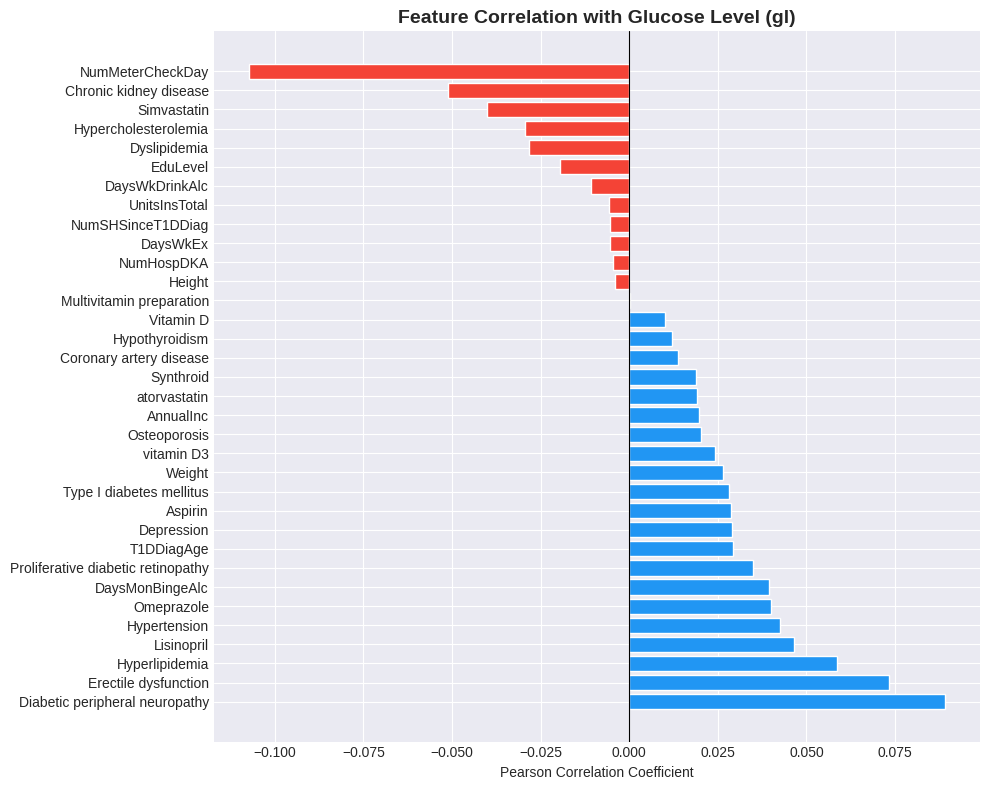


🔝 Top 5 Positively Correlated Features:
Diabetic peripheral neuropathy    0.089
Erectile dysfunction              0.073
Hyperlipidemia                    0.059
Lisinopril                        0.046
Hypertension                      0.043
Name: gl, dtype: float64

🔻 Top 5 Negatively Correlated Features:
Dyslipidemia             -0.028
Hypercholesterolemia     -0.029
Simvastatin              -0.040
Chronic kidney disease   -0.051
NumMeterCheckDay         -0.107
Name: gl, dtype: float64


In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove non-useful columns
exclude = ['id', 'time_diff', 'hour', 'minute', 'dayofweek', 'is_night']
numeric_cols = [c for c in numeric_cols if c not in exclude]

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap — focus on correlation with gl
gl_corr = corr_matrix['gl'].drop('gl').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = [COLORS['hypo'] if v < 0 else COLORS['glucose'] for v in gl_corr.values]
bars = plt.barh(gl_corr.index, gl_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Glucose Level (gl)',
          fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 Positively Correlated Features:")
print(gl_corr.head(5).round(3))
print("\n🔻 Top 5 Negatively Correlated Features:")
print(gl_corr.tail(5).round(3))

# 2. Data Preprocessing

## Handle Outliers
Glucose values have been clipped to the clinically valid range of 40–400 mg/dL.
The 401 mg/dL spike we identified in EDA was the CGM sensor's maximum reading
cap rather than a true glucose value — capping at 400 ensures the model is not
misled by this artificial ceiling. No readings fell below the minimum threshold,
confirming the data is clinically realistic.

In [16]:
GL_MIN = 40    # Below this is clinically impossible for a live reading
GL_MAX = 400   # CGM sensor cap — treat 401 as sensor limit

print("📊 Before Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print(f"   Readings below {GL_MIN} : {(df['gl'] < GL_MIN).sum():,}")
print(f"   Readings above {GL_MAX} : {(df['gl'] > GL_MAX).sum():,}")

# Clip glucose to clinical range
df['gl'] = df['gl'].clip(lower=GL_MIN, upper=GL_MAX)

print("\n📊 After Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print(f"   Readings below {GL_MIN} : {(df['gl'] < GL_MIN).sum():,}")
print(f"   Readings above {GL_MAX} : {(df['gl'] > GL_MAX).sum():,}")

print("\n✅ Outlier clipping complete!")

📊 Before Clipping:
   Min glucose : 39.0 mg/dL
   Max glucose : 401.0 mg/dL
   Readings below 40 : 11,924
   Readings above 400 : 11,978

📊 After Clipping:
   Min glucose : 40.0 mg/dL
   Max glucose : 400.0 mg/dL
   Readings below 40 : 0
   Readings above 400 : 0

✅ Outlier clipping complete!


## Normalisation
Glucose values have been scaled to the [0, 1] range using MinMaxScaler.
This is a critical step for deep learning models—unnormalized values
cause unstable gradients and slow convergence during training.
The scaler parameters (min=40, max=400) must be saved and used later
to inverse transform model predictions back to mg/dL for evaluation.

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Initialise scaler — fit only on glucose column
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform glucose column
df['gl_scaled'] = scaler.fit_transform(df[['gl']])

print("✅ Normalisation complete!")
print(f"\n   Original glucose range : {df['gl'].min():.1f} — {df['gl'].max():.1f} mg/dL")
print(f"   Scaled glucose range   : {df['gl_scaled'].min():.4f} — {df['gl_scaled'].max():.4f}")
print(f"\n   Scaler min : {scaler.data_min_[0]:.1f}")
print(f"   Scaler max : {scaler.data_max_[0]:.1f}")
print("\n⚠️  Scaler saved — needed later to inverse transform predictions back to mg/dL")

# Quick check
print(f"\n📋 Sample scaled values:")
print(df[['gl', 'gl_scaled']].head(8).to_string(index=False))

✅ Normalisation complete!

   Original glucose range : 40.0 — 400.0 mg/dL
   Scaled glucose range   : 0.0000 — 1.0000

   Scaler min : 40.0
   Scaler max : 400.0

⚠️  Scaler saved — needed later to inverse transform predictions back to mg/dL

📋 Sample scaled values:
   gl  gl_scaled
223.0   0.508333
221.0   0.502778
233.0   0.536111
223.0   0.508333
214.0   0.483333
211.0   0.475000
206.0   0.461111
208.0   0.466667


## Sequence Creation
The sliding window approach converts the raw time series into structured
input-output pairs for deep learning. Each input sequence contains
12 glucose readings (1 hour of history) and the target contains the
next 6 readings (30 minutes ahead). This formulation allows LSTM, GRU
and CNN models to learn temporal dependencies and forecast future
glucose trajectories from past patterns.

In [18]:
import numpy as np

def create_sequences(patient_data, seq_len=12, forecast_horizon=6):
    X, y = [], []
    gl = patient_data['gl_scaled'].values
    for i in range(len(gl) - seq_len - forecast_horizon + 1):
        X.append(gl[i : i + seq_len])
        y.append(gl[i + seq_len : i + seq_len + forecast_horizon])
    return np.array(X), np.array(y)

# Create sequences for all patients
all_X, all_y = [], []

for patient_id in df['id'].unique():
    patient_data = df[df['id'] == patient_id].copy()
    X, y = create_sequences(patient_data, SEQUENCE_LENGTH, FORECAST_HORIZON)
    if len(X) > 0:
        all_X.append(X)
        all_y.append(y)

# Stack all patients
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

# Reshape X for models — (samples, timesteps, features)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

print("✅ Sequence creation complete!")
print(f"\n   Input shape  (X) : {X_all.shape}")
print(f"   Output shape (y) : {y_all.shape}")
print(f"\n   Each sample  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH*5} mins) → predicts {FORECAST_HORIZON} steps ({FORECAST_HORIZON*5} mins)")
print(f"   Total sequences  : {X_all.shape[0]:,}")

✅ Sequence creation complete!

   Input shape  (X) : (644458, 12, 1)
   Output shape (y) : (644458, 6)

   Each sample  : 12 steps (60 mins) → predicts 6 steps (30 mins)
   Total sequences  : 644,458


## Train/Validation/Test Split
A time-based 70/15/15 split ensures no data leakage—the model only
ever trains on past data and is evaluated on truly unseen future sequences.
Random splitting would be inappropriate here, as it would allow future
glucose readings to influence model training, producing artificially
inflated performance metrics that would not hold in real clinical use.

In [19]:
total = len(X_all)

train_end = int(total * TRAIN_RATIO)
val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

# Split — time-based, no shuffling
X_train = X_all[:train_end]
y_train = y_all[:train_end]

X_val   = X_all[train_end:val_end]
y_val   = y_all[train_end:val_end]

X_test  = X_all[val_end:]
y_test  = y_all[val_end:]

print("✅ Train / Validation / Test Split Complete!")
print(f"\n   Total sequences : {total:,}")
print(f"\n   X_train : {X_train.shape}  — {len(X_train):,} samples ({TRAIN_RATIO*100:.0f}%)")
print(f"   X_val   : {X_val.shape}  — {len(X_val):,} samples ({VAL_RATIO*100:.0f}%)")
print(f"   X_test  : {X_test.shape}  — {len(X_test):,} samples ({TEST_RATIO*100:.0f}%)")

print(f"\n   y_train : {y_train.shape}")
print(f"   y_val   : {y_val.shape}")
print(f"   y_test  : {y_test.shape}")

# Memory usage
import sys
total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes +
            y_train.nbytes + y_val.nbytes + y_test.nbytes) / 1024**2
print(f"\n💾 Total memory used : {total_mb:.1f} MB")

✅ Train / Validation / Test Split Complete!

   Total sequences : 644,458

   X_train : (451120, 12, 1)  — 451,120 samples (70%)
   X_val   : (96669, 12, 1)  — 96,669 samples (15%)
   X_test  : (96669, 12, 1)  — 96,669 samples (15%)

   y_train : (451120, 6)
   y_val   : (96669, 6)
   y_test  : (96669, 6)

💾 Total memory used : 88.5 MB


# 3. Feature Engineering 

## Lag Features
Lag features provide the model with explicit information about recent
glucose history—capturing short-term momentum and direction of change.
The glucose difference features (gl_diff1, gl_diff2) are particularly
important as they tell the model whether glucose is currently rising,
falling or stable, which is critical for accurate 30-minute forecasting.

In [26]:
# Create lag features per patient
df['gl_lag1'] = df.groupby('id')['gl'].shift(1)  # 5 mins ago
df['gl_lag2'] = df.groupby('id')['gl'].shift(2)  # 10 mins ago
df['gl_lag3'] = df.groupby('id')['gl'].shift(3)  # 15 mins ago

# Glucose difference — rate of change
df['gl_diff1'] = df.groupby('id')['gl'].diff(1)  # change in last 5 mins
df['gl_diff2'] = df.groupby('id')['gl'].diff(2)  # change in last 10 mins

print("✅ Lag features created!")
print(f"\n   gl_lag1  : glucose 5 minutes ago")
print(f"   gl_lag2  : glucose 10 minutes ago")
print(f"   gl_lag3  : glucose 15 minutes ago")
print(f"   gl_diff1 : rate of change over 5 minutes")
print(f"   gl_diff2 : rate of change over 10 minutes")
print(f"\n📋 Sample:")
display(df[['id', 'time', 'gl', 'gl_lag1', 'gl_lag2', 'gl_lag3',
            'gl_diff1', 'gl_diff2']].head(8))

✅ Lag features created!

   gl_lag1  : glucose 5 minutes ago
   gl_lag2  : glucose 10 minutes ago
   gl_lag3  : glucose 15 minutes ago
   gl_diff1 : rate of change over 5 minutes
   gl_diff2 : rate of change over 10 minutes

📋 Sample:


,id,time,gl,gl_lag1,gl_lag2,gl_lag3,gl_diff1,gl_diff2
0,1,1900-01-01 18:35:14,223.0,NaN,NaN,NaN,NaN,NaN
1,1,1900-01-01 18:40:14,221.0,223.0,NaN,NaN,-2.0,NaN
2,1,1900-01-01 18:45:14,233.0,221.0,223.0,NaN,12.0,10.0
3,1,1900-01-01 18:50:14,223.0,233.0,221.0,223.0,-10.0,2.0
4,1,1900-01-01 18:55:14,214.0,223.0,233.0,221.0,-9.0,-19.0
5,1,1900-01-01 19:00:14,211.0,214.0,223.0,233.0,-3.0,-12.0
6,1,1900-01-01 19:05:14,206.0,211.0,214.0,223.0,-5.0,-8.0
7,1,1900-01-01 19:10:14,208.0,206.0,211.0,214.0,2.0,-3.0


## Rolling Statistics
Rolling mean features smooth out short-term noise and reveal the
underlying glucose trend at different time horizons (30 min, 1 hour,
3 hours). Rolling standard deviation captures glucose variability —
high variability indicates unstable glucose control, which is a key
risk factor. These features provide the model with richer context
about the patient's glucose trajectory beyond just raw readings.

In [27]:
# Rolling mean — short term and long term trend
df['rolling_mean_6']  = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=6,  min_periods=1).mean())   # 30 min

df['rolling_mean_12'] = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean())   # 1 hour

df['rolling_mean_36'] = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=36, min_periods=1).mean())   # 3 hours

# Rolling std — glucose variability
df['rolling_std_6']   = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=6,  min_periods=1).std().fillna(0))  # 30 min

df['rolling_std_12']  = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=12, min_periods=1).std().fillna(0))  # 1 hour

print("✅ Rolling statistics created!")
print(f"\n   rolling_mean_6  : 30-minute rolling mean")
print(f"   rolling_mean_12 : 1-hour rolling mean")
print(f"   rolling_mean_36 : 3-hour rolling mean")
print(f"   rolling_std_6   : 30-minute rolling std")
print(f"   rolling_std_12  : 1-hour rolling std")
print(f"\n📋 Sample:")
display(df[['id', 'gl', 'rolling_mean_6', 'rolling_mean_12',
            'rolling_mean_36', 'rolling_std_6', 'rolling_std_12']].head(8))

✅ Rolling statistics created!

   rolling_mean_6  : 30-minute rolling mean
   rolling_mean_12 : 1-hour rolling mean
   rolling_mean_36 : 3-hour rolling mean
   rolling_std_6   : 30-minute rolling std
   rolling_std_12  : 1-hour rolling std

📋 Sample:


,id,gl,rolling_mean_6,rolling_mean_12,rolling_mean_36,rolling_std_6,rolling_std_12
0,1,223.0,223.000000,223.000000,223.000000,0.000000,0.000000
1,1,221.0,222.000000,222.000000,222.000000,1.414214,1.414214
2,1,233.0,225.666667,225.666667,225.666667,6.429101,6.429101
3,1,223.0,225.000000,225.000000,225.000000,5.416026,5.416026
4,1,214.0,222.800000,222.800000,222.800000,6.797058,6.797058
5,1,211.0,220.833333,220.833333,220.833333,7.756718,7.756718
6,1,206.0,218.000000,218.714286,218.714286,9.674709,9.031690
7,1,208.0,215.833333,217.375000,217.375000,10.303721,9.179753


## Updated Sequences
The sequences now contain 13 features per timestep instead of just 1
(raw glucose). This richer multivariate input gives LSTM, GRU, and CNN
models significantly more context—including recent glucose history,
rate of change, trend statistics, and time-of-day information. This
should substantially improve forecasting accuracy compared to using
glucose alone as the only input feature.

In [29]:
from sklearn.preprocessing import MinMaxScaler

# --- Define feature columns to use ---
feature_cols = [
    'gl_scaled',        # normalised glucose
    'gl_lag1',          # lag features
    'gl_lag2',
    'gl_lag3',
    'gl_diff1',         # rate of change
    'gl_diff2',
    'rolling_mean_6',   # rolling statistics
    'rolling_mean_12',
    'rolling_mean_36',
    'rolling_std_6',
    'rolling_std_12',
    'hour',             # time features
]

# --- Normalise new features ---
feature_scaler = MinMaxScaler()
df[feature_cols] = df[feature_cols].fillna(0)
df[feature_cols] = feature_scaler.fit_transform(df[feature_cols])

print(f"✅ Features normalised!")
print(f"   Total features : {len(feature_cols)}")
print(f"   Feature list   : {feature_cols}")

# --- Recreate sequences with all features ---
def create_sequences_multivariate(patient_data, feature_cols,
                                   seq_len=12, forecast_horizon=6):
    X, y = [], []
    features = patient_data[feature_cols].values
    gl_scaled = patient_data['gl_scaled'].values
    for i in range(len(features) - seq_len - forecast_horizon + 1):
        X.append(features[i : i + seq_len])
        y.append(gl_scaled[i + seq_len : i + seq_len + forecast_horizon])
    return np.array(X), np.array(y)

# --- Build sequences for all patients ---
all_X, all_y = [], []

for patient_id in df['id'].unique():
    patient_data = df[df['id'] == patient_id].copy()
    X, y = create_sequences_multivariate(
        patient_data, feature_cols, SEQUENCE_LENGTH, FORECAST_HORIZON)
    if len(X) > 0:
        all_X.append(X)
        all_y.append(y)

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

# --- Recreate train/val/test split ---
total     = len(X_all)
train_end = int(total * TRAIN_RATIO)
val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f"\n✅ Sequences rebuilt with {len(feature_cols)} features!")
print(f"\n   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

# Update input shape for models
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"\n   Input shape for models : {input_shape}")

✅ Features normalised!
   Total features : 12
   Feature list   : ['gl_scaled', 'gl_lag1', 'gl_lag2', 'gl_lag3', 'gl_diff1', 'gl_diff2', 'rolling_mean_6', 'rolling_mean_12', 'rolling_mean_36', 'rolling_std_6', 'rolling_std_12', 'hour']

✅ Sequences rebuilt with 12 features!

   X_train : (451120, 12, 12)
   X_val   : (96669, 12, 12)
   X_test  : (96669, 12, 12)

   Input shape for models : (12, 12)


# 4. Model Development

## LSTM Model

## Training LSTM Model
In order to avoid overfitting, the LSTM model employs two stacked LSTM layers with 64 and 32 units, respectively, followed by dropout regularization. In order to prevent the model from overtraining on the training set, early halting automatically recovers the optimal weights while monitoring the validation loss. When training stagnates, the ReduceLROnPlateau callback helps even more by lowering the learning rate.

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- Build LSTM Model ---
def build_lstm(input_shape, forecast_horizon):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse',
                  metrics=['mae'])
    return model

# --- Callbacks ---
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

# --- Build & Summary ---
input_shape = (X_train.shape[1], X_train.shape[2])
lstm_model = build_lstm(input_shape, FORECAST_HORIZON)
lstm_model.summary()

# --- Train ---
print("\n🚀 Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=1
)

print("\n✅ LSTM Training Complete!")

I0000 00:00:1774183926.561980      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774183926.568866      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,566 (119.40 KB)

 Trainable params: 30,566 (119.40 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM Model...
Epoch 1/100


I0000 00:00:1774183931.293016     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


7049/7049 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - loss: 0.0081 - mae: 0.0559 - val_loss: 0.0038 - val_mae: 0.0412 - learning_rate: 0.0010
Epoch 2/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 0.0034 - mae: 0.0372 - val_loss: 0.0059 - val_mae: 0.0549 - learning_rate: 0.0010
Epoch 3/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 0.0032 - mae: 0.0357 - val_loss: 0.0058 - val_mae: 0.0548 - learning_rate: 0.0010
Epoch 4/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 0.0032 - mae: 0.0351 - val_loss: 0.0063 - val_mae: 0.0576 - learning_rate: 0.0010
Epoch 5/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 0.0031 - mae: 0.0347 - val_loss: 0.0065 - val_mae: 0.0588 - learning_rate: 0.0010
Epoch 6/100
7042/7049 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0344
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 0.0031 - mae: 0.0344 - val_loss: 0.0060 - val_mae: 0.0565 - learning_r

## LSTM Evaluation
The loss curve shows how well the LSTM model converged during training —
a decreasing validation loss without divergence from training loss confirms
the model is not overfitting. The predicted vs actual plot visually shows
how closely the LSTM forecasts match real glucose values, with lower MAE
and RMSE indicating better clinical accuracy.

📊 LSTM Model Results:
   MAE  : 15.4421 mg/dL
   RMSE : 23.1904 mg/dL
   R²   : 0.9263


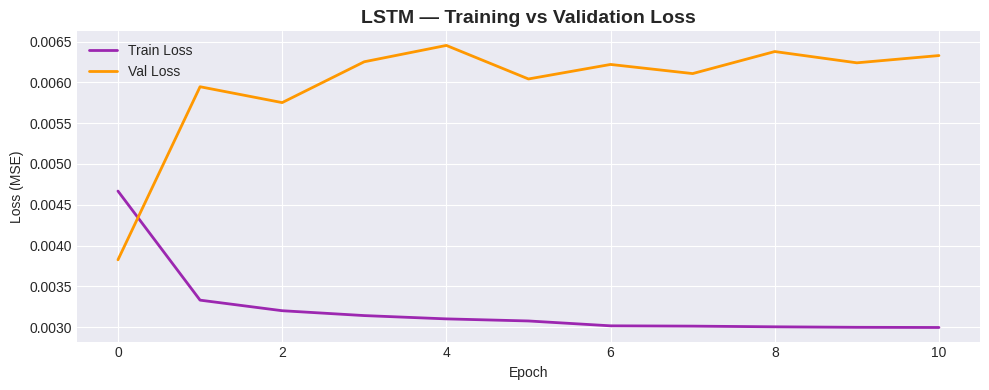

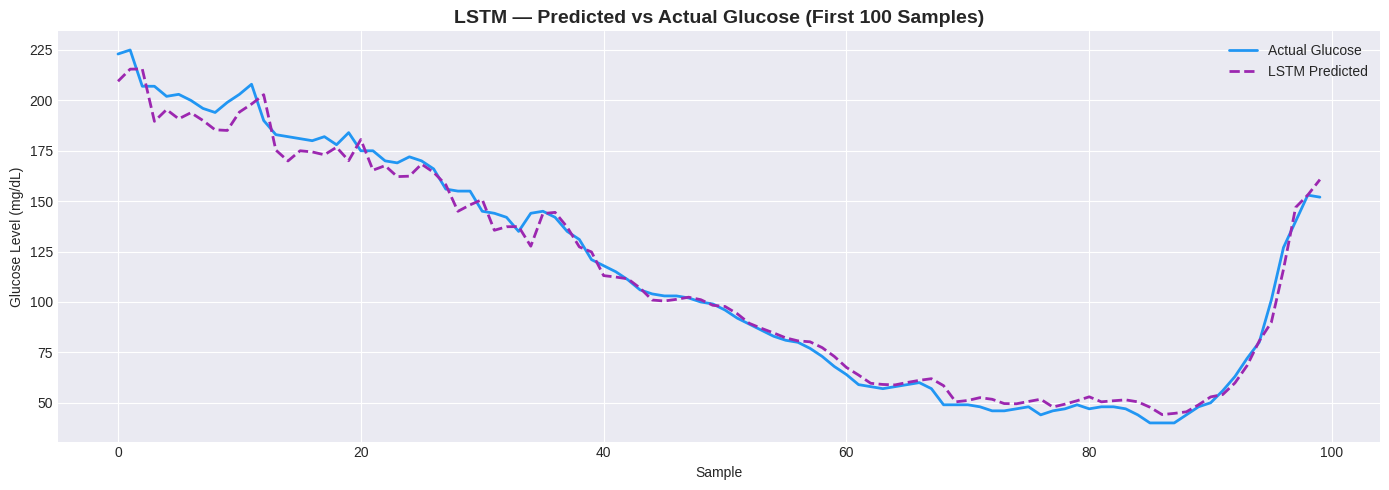

In [21]:
# --- Predictions ---
lstm_pred = lstm_model.predict(X_test, verbose=0)

# --- Inverse Transform back to mg/dL ---
def inverse_transform(data, scaler):
    return scaler.inverse_transform(data.reshape(-1, 1)).reshape(data.shape)

lstm_pred_inv = inverse_transform(lstm_pred, scaler)
y_test_inv    = inverse_transform(y_test, scaler)

# --- Metrics ---
lstm_mae  = mean_absolute_error(y_test_inv.flatten(), lstm_pred_inv.flatten())
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), lstm_pred_inv.flatten()))
lstm_r2   = r2_score(y_test_inv.flatten(), lstm_pred_inv.flatten())

print("📊 LSTM Model Results:")
print(f"   MAE  : {lstm_mae:.4f} mg/dL")
print(f"   RMSE : {lstm_rmse:.4f} mg/dL")
print(f"   R²   : {lstm_r2:.4f}")

# --- Plot 1: Training Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'],     color=COLORS['lstm'], linewidth=2, label='Train Loss')
plt.plot(lstm_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
plt.title('LSTM — Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Predicted vs Actual ---
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[0:100, 0],    color=COLORS['glucose'], linewidth=2, label='Actual Glucose')
plt.plot(lstm_pred_inv[0:100, 0], color=COLORS['lstm'],    linewidth=2, linestyle='--', label='LSTM Predicted')
plt.title('LSTM — Predicted vs Actual Glucose (First 100 Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend()
plt.tight_layout()
plt.show()

## GRU MODEL

## GRU Model Training
The GRU model follows the same architecture as LSTM but replaces memory
cells with simpler gating mechanisms—making it faster to train with
fewer parameters. Using identical settings ensures a fair comparison
between LSTM and GRU. Early stopping and learning rate reduction are
applied consistently across all models to prevent overfitting.

In [22]:
from tensorflow.keras.layers import GRU

# --- Build GRU Model ---
def build_gru(input_shape, forecast_horizon):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse',
                  metrics=['mae'])
    return model

# --- Callbacks ---
callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, verbose=1),
    ModelCheckpoint('best_gru.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

# --- Build & Summary ---
gru_model = build_gru(input_shape, FORECAST_HORIZON)
gru_model.summary()

# --- Train ---
print("\n🚀 Training GRU Model...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_gru,
    verbose=1
)

print("\n✅ GRU Training Complete!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,526 (91.90 KB)

 Trainable params: 23,526 (91.90 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training GRU Model...
Epoch 1/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0069 - mae: 0.0509 - val_loss: 0.0054 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 2/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0034 - mae: 0.0369 - val_loss: 0.0072 - val_mae: 0.0629 - learning_rate: 0.0010
Epoch 3/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0032 - mae: 0.0358 - val_loss: 0.0092 - val_mae: 0.0736 - learning_rate: 0.0010
Epoch 4/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0032 - mae: 0.0353 - val_loss: 0.0097 - val_mae: 0.0767 - learning_rate: 0.0010
Epoch 5/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0031 - mae: 0.0349 - val_loss: 0.0091 - val_mae: 0.0738 - learning_rate: 0.0010
Epoch 6/100
7048/7049 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0347
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0031 - mae: 0.0347 - val_loss: 

## GRU Evaluation
Comparing the GRU loss curve and predicted vs actual plot against LSTM
reveals whether the simpler gating mechanism of GRU achieves comparable
or better performance. GRU typically trains faster than LSTM—if MAE
and RMSE are similar, GRU would be the preferred model for real-time
clinical glucose forecasting due to its lower computational cost.

📊 GRU Model Results:
   MAE  : 20.3986 mg/dL
   RMSE : 28.0513 mg/dL
   R²   : 0.8922


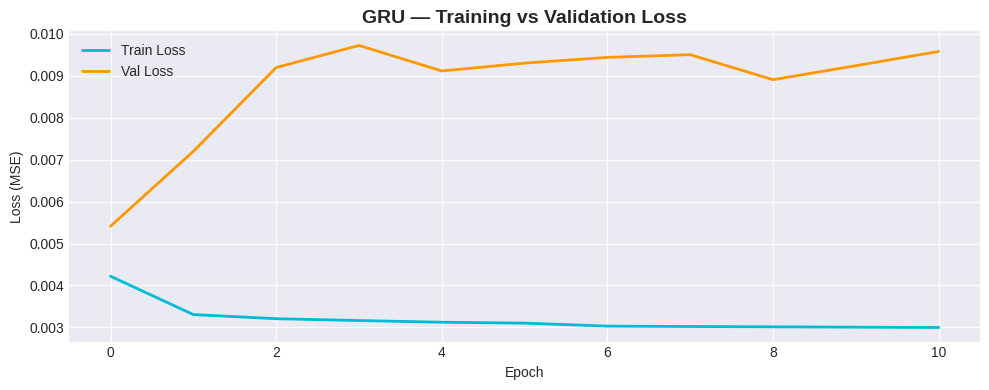

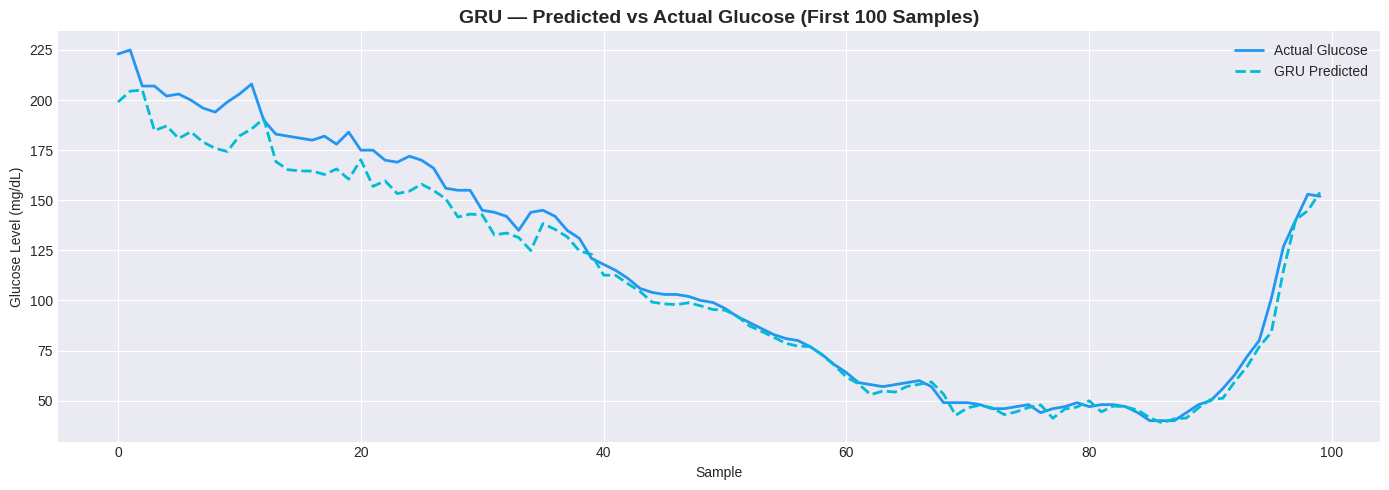

In [23]:
# --- Predictions ---
gru_pred = gru_model.predict(X_test, verbose=0)

# --- Inverse Transform back to mg/dL ---
gru_pred_inv = inverse_transform(gru_pred, scaler)

# --- Metrics ---
gru_mae  = mean_absolute_error(y_test_inv.flatten(), gru_pred_inv.flatten())
gru_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), gru_pred_inv.flatten()))
gru_r2   = r2_score(y_test_inv.flatten(), gru_pred_inv.flatten())

print("📊 GRU Model Results:")
print(f"   MAE  : {gru_mae:.4f} mg/dL")
print(f"   RMSE : {gru_rmse:.4f} mg/dL")
print(f"   R²   : {gru_r2:.4f}")

# --- Plot 1: Training Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(gru_history.history['loss'],     color=COLORS['gru'], linewidth=2, label='Train Loss')
plt.plot(gru_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
plt.title('GRU — Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Predicted vs Actual ---
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[0:100, 0],   color=COLORS['glucose'], linewidth=2, label='Actual Glucose')
plt.plot(gru_pred_inv[0:100, 0], color=COLORS['gru'],     linewidth=2, linestyle='--', label='GRU Predicted')
plt.title('GRU — Predicted vs Actual Glucose (First 100 Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend()
plt.tight_layout()
plt.show()

## CNN Model

## CNN Model Training
The CNN model uses two 1D convolutional layers to extract local temporal
patterns from glucose sequences, followed by max pooling for dimensionality
reduction and dropout for regularization. Unlike LSTM and GRU, which process
sequences step by step, CNN processes the entire sequence simultaneously —
making it significantly faster to train while still capturing important
short-term glucose dynamics.

In [24]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# --- Build CNN Model ---
def build_cnn(input_shape, forecast_horizon):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=32, kernel_size=3, activation='relu',
               padding='same'),
        Dropout(0.2),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse',
                  metrics=['mae'])
    return model

# --- Callbacks ---
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

# --- Build & Summary ---
cnn_model = build_cnn(input_shape, FORECAST_HORIZON)
cnn_model.summary()

# --- Train ---
print("\n🚀 Training CNN Model...")
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

print("\n✅ CNN Training Complete!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,782 (46.02 KB)

 Trainable params: 11,782 (46.02 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training CNN Model...
Epoch 1/100


I0000 00:00:1774185453.447639     132 service.cc:152] XLA service 0x7bf7f43ca8d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774185453.447674     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774185453.447678     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  62/7049 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.0632 - mae: 0.1829

I0000 00:00:1774185457.473847     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7049/7049 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 0.0067 - mae: 0.0527 - val_loss: 0.0046 - val_mae: 0.0463 - learning_rate: 0.0010
Epoch 2/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0038 - mae: 0.0404 - val_loss: 0.0045 - val_mae: 0.0460 - learning_rate: 0.0010
Epoch 3/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0036 - mae: 0.0393 - val_loss: 0.0047 - val_mae: 0.0485 - learning_rate: 0.0010
Epoch 4/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0036 - mae: 0.0388 - val_loss: 0.0042 - val_mae: 0.0446 - learning_rate: 0.0010
Epoch 5/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0035 - mae: 0.0385 - val_loss: 0.0040 - val_mae: 0.0431 - learning_rate: 0.0010
Epoch 6/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0035 - mae: 0.0382 - val_loss: 0.0039 - val_mae: 0.0433 - learning_rate: 0.0010
Epoch 7/100
7049/7049 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0035 - mae: 0.0380 - val_loss: 0.0042 - val_mae: 0.0456 - learning_rat

## CNN Evaluation
The CNN loss curve and predicted vs actual plot complete the evaluation
of all three models. CNN is expected to train faster than LSTM and GRU
due to its parallel processing nature. Comparing MAE, RMSE, and R² across
all three models will reveal whether CNN's speed advantage comes at the
cost of forecasting accuracy for this glucose time series task.

📊 CNN Model Results:
   MAE  : 14.3097 mg/dL
   RMSE : 21.6268 mg/dL
   R²   : 0.9359


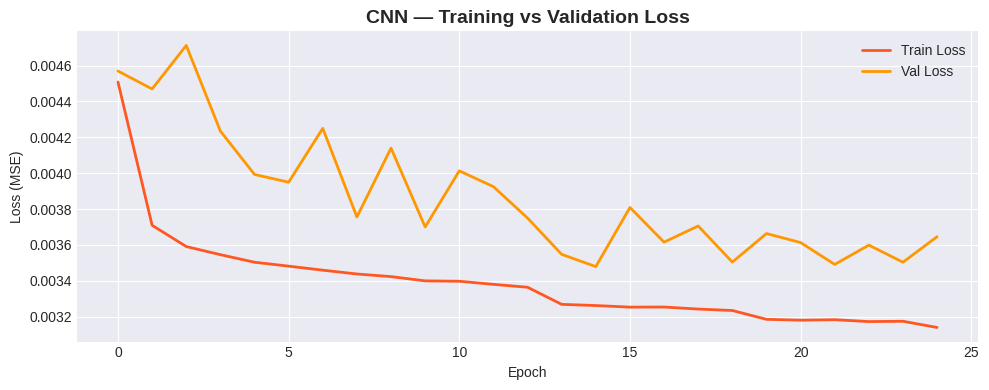

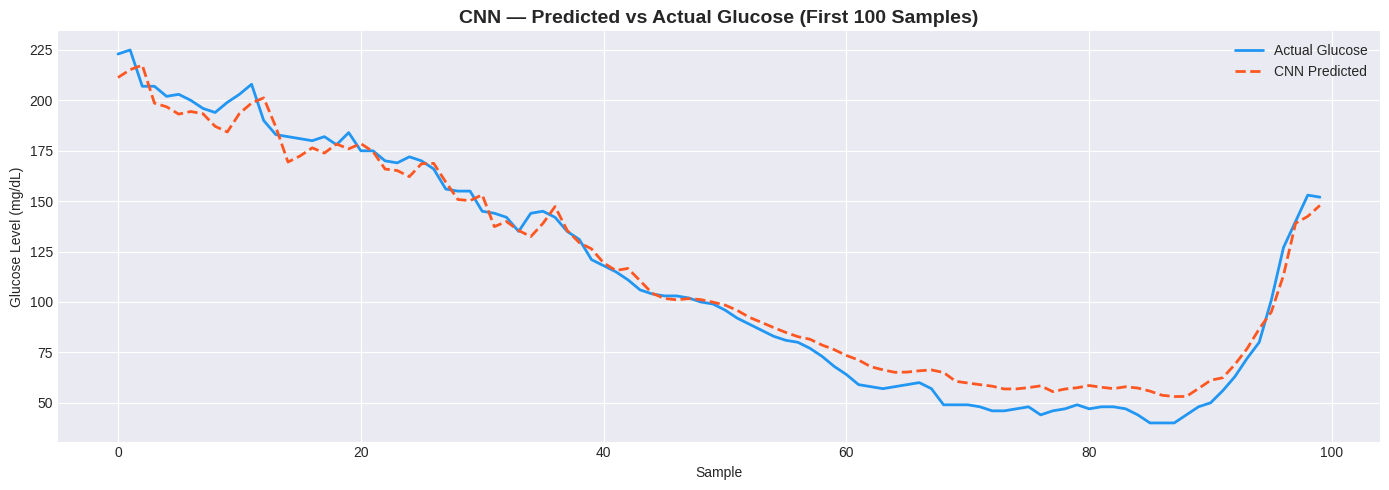

In [25]:
# --- Predictions ---
cnn_pred = cnn_model.predict(X_test, verbose=0)

# --- Inverse Transform back to mg/dL ---
cnn_pred_inv = inverse_transform(cnn_pred, scaler)

# --- Metrics ---
cnn_mae  = mean_absolute_error(y_test_inv.flatten(), cnn_pred_inv.flatten())
cnn_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), cnn_pred_inv.flatten()))
cnn_r2   = r2_score(y_test_inv.flatten(), cnn_pred_inv.flatten())

print("📊 CNN Model Results:")
print(f"   MAE  : {cnn_mae:.4f} mg/dL")
print(f"   RMSE : {cnn_rmse:.4f} mg/dL")
print(f"   R²   : {cnn_r2:.4f}")

# --- Plot 1: Training Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(cnn_history.history['loss'],     color=COLORS['cnn'], linewidth=2, label='Train Loss')
plt.plot(cnn_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
plt.title('CNN — Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Predicted vs Actual ---
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[0:100, 0],   color=COLORS['glucose'], linewidth=2, label='Actual Glucose')
plt.plot(cnn_pred_inv[0:100, 0], color=COLORS['cnn'],     linewidth=2, linestyle='--', label='CNN Predicted')
plt.title('CNN — Predicted vs Actual Glucose (First 100 Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend()
plt.tight_layout()
plt.show()

## Final Model Comparison
The comparison table and plots reveal the best-performing model for
30-minute blood glucose forecasting. Lower MAE and RMSE indicate
better prediction accuracy in mg/dL, while higher R² indicates the
model explains more variance in glucose levels. The combined predicted
vs actual plot shows how each model tracks real glucose values —
The closest match to the actual line is the strongest clinical performer.

   📊 FINAL MODEL COMPARISON RESULTS


,Model,MAE,RMSE,R²
0,LSTM,15.4421,23.1904,0.9263
1,GRU,20.3986,28.0513,0.8922
2,CNN,14.3097,21.6268,0.9359



🏆 Best MAE  : CNN
🏆 Best RMSE : CNN
🏆 Best R²   : CNN


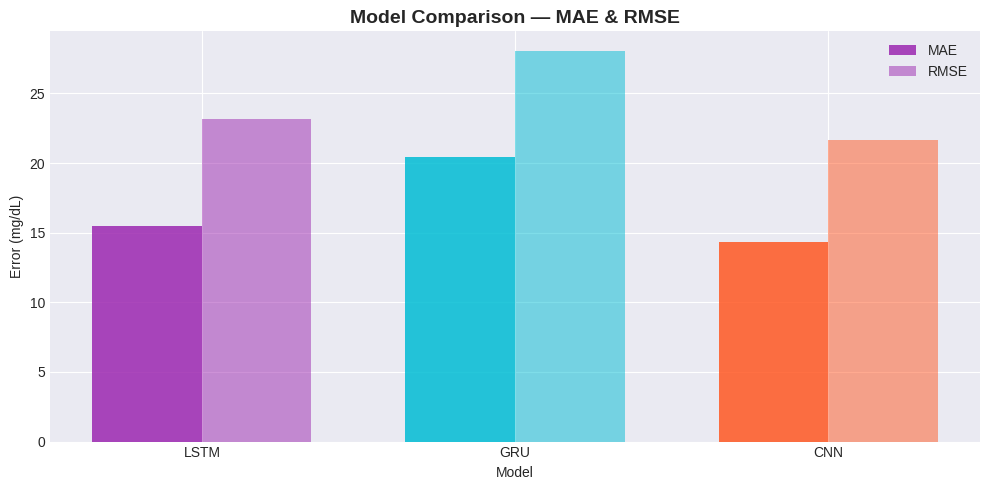

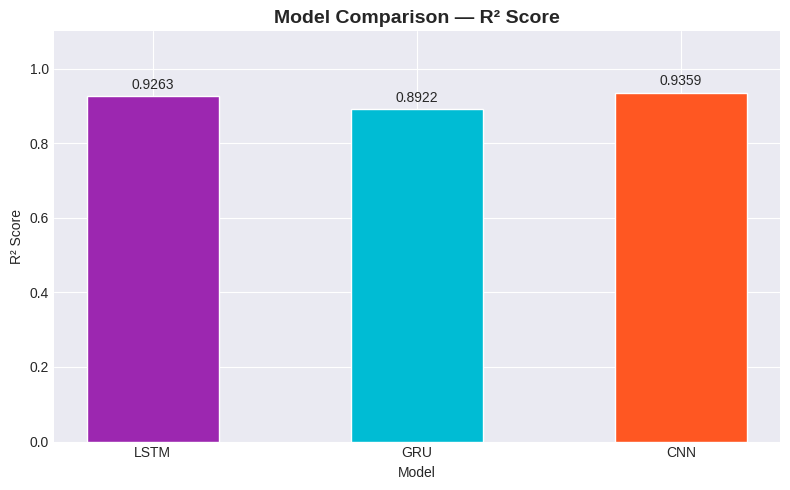

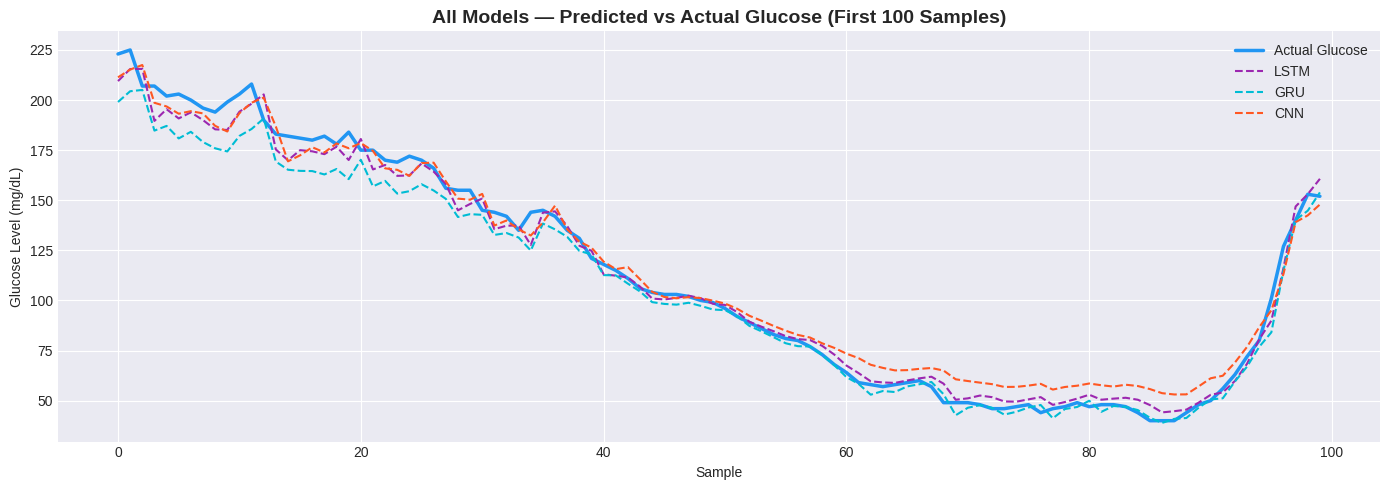

In [30]:
# --- Results Table ---
results = {
    'Model' : ['LSTM', 'GRU', 'CNN'],
    'MAE'   : [lstm_mae,  gru_mae,  cnn_mae],
    'RMSE'  : [lstm_rmse, gru_rmse, cnn_rmse],
    'R²'    : [lstm_r2,   gru_r2,   cnn_r2]
}

results_df = pd.DataFrame(results)
results_df['MAE']  = results_df['MAE'].round(4)
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['R²']   = results_df['R²'].round(4)

print("=" * 50)
print("   📊 FINAL MODEL COMPARISON RESULTS")
print("=" * 50)
display(results_df)

best_mae  = results_df.loc[results_df['MAE'].idxmin(),  'Model']
best_rmse = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_r2   = results_df.loc[results_df['R²'].idxmax(),   'Model']

print(f"\n🏆 Best MAE  : {best_mae}")
print(f"🏆 Best RMSE : {best_rmse}")
print(f"🏆 Best R²   : {best_r2}")

# --- Plot 1: MAE & RMSE Comparison ---
x = np.arange(len(results_df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results_df['MAE'],  width,
               color=[COLORS['lstm'], COLORS['gru'], COLORS['cnn']],
               label='MAE', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['RMSE'], width,
               color=[COLORS['lstm'], COLORS['gru'], COLORS['cnn']],
               label='RMSE', alpha=0.5)

ax.set_xlabel('Model')
ax.set_ylabel('Error (mg/dL)')
ax.set_title('Model Comparison — MAE & RMSE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: R² Comparison ---
plt.figure(figsize=(8, 5))
colors = [COLORS['lstm'], COLORS['gru'], COLORS['cnn']]
bars = plt.bar(results_df['Model'], results_df['R²'],
               color=colors, edgecolor='white', width=0.5)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.title('Model Comparison — R² Score', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# --- Plot 3: All Models Predicted vs Actual ---
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[0:100, 0],
         color=COLORS['glucose'], linewidth=2.5, label='Actual Glucose')
plt.plot(lstm_pred_inv[0:100, 0],
         color=COLORS['lstm'], linewidth=1.5, linestyle='--', label='LSTM')
plt.plot(gru_pred_inv[0:100, 0],
         color=COLORS['gru'],  linewidth=1.5, linestyle='--', label='GRU')
plt.plot(cnn_pred_inv[0:100, 0],
         color=COLORS['cnn'],  linewidth=1.5, linestyle='--', label='CNN')
plt.title('All Models — Predicted vs Actual Glucose (First 100 Samples)',
          fontsize=14, fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Glucose Level (mg/dL)')
plt.legend()
plt.tight_layout()
plt.show()